# 02 — Data Cleaning, Alignment, and Indicator Construction (θ)

This notebook implements:

US3 — Data Cleaning & Alignment  
US4 — Labour Market Imbalance Indicator Construction

The objective is to construct a consistent, transparent, and reproducible
monthly labour market dataset suitable for:

• Descriptive analysis  
• Diagnostic analysis  
• Predictive forecasting  
• Scenario modeling  

---

Compute labour market imbalance indicator:
   
   θₜ = Vₜ / Uₜ

   where:
   - Vₜ = job vacancies (persons)
   - Uₜ = unemployed persons

To ensure measurement consistency:

- Unemployment is converted from thousands to persons.
- Vacancies are already expressed in persons.

---

## COVID Structural Shock Treatment

Following supervisory guidance:

• The April–September 2020 period is retained for descriptive and diagnostic analysis.
• The same period is excluded from predictive modeling to preserve trend stability.

Two datasets will therefore be exported:

1. `final_dataset_full.csv`
2. `final_dataset_modeling.csv`


In [215]:
# ---------------------------------------------------
# STEP 1.1 — Environment Setup
# ---------------------------------------------------

import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Define project paths
PROJECT_ROOT = Path("..")
RAW_DATA = PROJECT_ROOT / "1_data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "1_data" / "processed"

In [ ]:
# ---------------------------------------------------
# STEP 1.2 — Load raw datasets
# ---------------------------------------------------

lfs_raw = pd.read_csv(RAW_DATA / "maindata.csv")
vac_raw = pd.read_csv(RAW_DATA / "job_vacancies.csv")

print("LFS raw shape:", lfs_raw.shape)
print("Vacancy raw shape:", vac_raw.shape)

LFS raw shape: (2208, 19)
Vacancy raw shape: (552, 3)


In [217]:
# ---------------------------------------------------
# STEP 1.3 — Dataset Structure Inspection
# ---------------------------------------------------

def inspect_dataset(df, name):
    print(f"\n{name} dataset inspection")
    print("-" * 50)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nFirst 5 rows:")
    display(df.head())


inspect_dataset(lfs_raw, "Labour Force Survey")
inspect_dataset(vac_raw, "Job Vacancy")


Labour Force Survey dataset inspection
--------------------------------------------------
Shape: (2208, 19)

Columns:
['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender', 'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

Data types:
REF_DATE                         object
GEO                              object
DGUID                            object
Labour force characteristics     object
Gender                           object
Age group                        object
Statistics                       object
Data type                        object
UOM                              object
UOM_ID                            int64
SCALAR_FACTOR                    object
SCALAR_ID                         int64
VECTOR                           object
COORDINATE                       object
VALUE                           float64
STATUS                         

,REF_DATE,GEO,DGUID,Labour force characteristics,Gender,Age group,Statistics,Data type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1980-01,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,18317.9,NaN,NaN,NaN,1
1,1980-02,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,18346.4,NaN,NaN,NaN,1
2,1980-03,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,18373.9,NaN,NaN,NaN,1
3,1980-04,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,18407.7,NaN,NaN,NaN,1
4,1980-05,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,18437.0,NaN,NaN,NaN,1



Job Vacancy dataset inspection
--------------------------------------------------
Shape: (552, 3)

Columns:
['month', 'vacancies_final', 'vacancies_final_source']

Data types:
month                      object
vacancies_final           float64
vacancies_final_source     object
dtype: object

First 5 rows:


,month,vacancies_final,vacancies_final_source
0,1980-01-01,273345.0,HWI_scaled_to_CFIB_then_StatCan
1,1980-02-01,259678.0,HWI_scaled_to_CFIB_then_StatCan
2,1980-03-01,254211.0,HWI_scaled_to_CFIB_then_StatCan
3,1980-04-01,256944.0,HWI_scaled_to_CFIB_then_StatCan
4,1980-05-01,235077.0,HWI_scaled_to_CFIB_then_StatCan


In [218]:
print("LFS columns:")
print(lfs_raw.columns)

print("\nVacancy columns:")
print(vac_raw.columns)

LFS columns:
Index(['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender', 'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE',
       'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

Vacancy columns:
Index(['month', 'vacancies_final', 'vacancies_final_source'], dtype='object')


In [219]:
# ---------------------------------------------------
# STEP 1.6 — Standardize time index
# ---------------------------------------------------

# Convert LFS date column
lfs_raw["month"] = pd.to_datetime(lfs_raw["REF_DATE"])

# Vacancy dataset already has month but ensure correct type
vac_raw["month"] = pd.to_datetime(vac_raw["month"])

# Sort both datasets
lfs_raw = lfs_raw.sort_values("month").reset_index(drop=True)
vac_raw = vac_raw.sort_values("month").reset_index(drop=True)

print("LFS date range:")
print(lfs_raw["month"].min(), "→", lfs_raw["month"].max())

print("\nVacancy date range:")
print(vac_raw["month"].min(), "→", vac_raw["month"].max())

LFS date range:
1980-01-01 00:00:00 → 2025-12-01 00:00:00

Vacancy date range:
1980-01-01 00:00:00 → 2025-12-01 00:00:00


In [220]:
# ---------------------------------------------------
# STEP 1.4 — Date column validation and conversion
# ---------------------------------------------------

# Convert date column to datetime
lfs_raw["month"] = pd.to_datetime(lfs_raw["month"])
vac_raw["month"] = pd.to_datetime(vac_raw["month"])

# Sort datasets chronologically
lfs_raw = lfs_raw.sort_values("month").reset_index(drop=True)
vac_raw = vac_raw.sort_values("month").reset_index(drop=True)

# Check date ranges
print("LFS date range:")
print("Start:", lfs_raw["month"].min())
print("End:", lfs_raw["month"].max())

print("\nVacancy date range:")
print("Start:", vac_raw["month"].min())
print("End:", vac_raw["month"].max())
print("\n===== DATE COVERAGE =====\n")

print("LFS first date:", lfs_raw["REF_DATE"].min())
print("LFS last date:", lfs_raw["REF_DATE"].max())
print("Unique months LFS:", lfs_raw["REF_DATE"].nunique())

print("\nVacancy first date:", vac_raw["month"].min())
print("Vacancy last date:", vac_raw["month"].max())
print("Unique months Vacancy:", vac_raw["month"].nunique())

LFS date range:
Start: 1980-01-01 00:00:00
End: 2025-12-01 00:00:00

Vacancy date range:
Start: 1980-01-01 00:00:00
End: 2025-12-01 00:00:00

===== DATE COVERAGE =====

LFS first date: 1980-01
LFS last date: 2025-12
Unique months LFS: 552

Vacancy first date: 1980-01-01 00:00:00
Vacancy last date: 2025-12-01 00:00:00
Unique months Vacancy: 552


In [221]:
# ---------------------------------------------------
# STEP 1.7 — Clean Labour Dataset Columns
# ---------------------------------------------------

# Keep only necessary columns
lfs_clean = lfs_raw[[
    "month",
    "VALUE",
    "Labour force characteristics"
]].copy()

# Preview
print("Cleaned LFS dataset shape:", lfs_clean.shape)
display(lfs_clean.head())

Cleaned LFS dataset shape: (2208, 3)


,month,VALUE,Labour force characteristics
0,1980-01-01,18317.9,Population
1,1980-01-01,11760.1,Labour force
2,1980-01-01,10882.6,Employment
3,1980-01-01,877.5,Unemployment
4,1980-02-01,11796.9,Labour force


In [222]:
# ---------------------------------------------------
# STEP 1.8 — Convert LFS long format → wide format
# ---------------------------------------------------

lfs_wide = (
    lfs_clean
    .pivot_table(
        index="month",
        columns="Labour force characteristics",
        values="VALUE"
    )
    .reset_index()
)

# Standardize column names
lfs_wide.columns = [
    "month",
    "employment",
    "labour_force",
    "population",
    "unemployment"
]

# Reorder columns to project standard
lfs_wide = lfs_wide[
    [
        "month",
        "employment",
        "unemployment",
        "labour_force",
        "population"
    ]
]

print("Wide LFS shape:", lfs_wide.shape)
display(lfs_wide.head())

Wide LFS shape: (552, 5)


,month,employment,unemployment,labour_force,population
0,1980-01-01,10882.6,877.5,11760.1,18317.9
1,1980-02-01,10902.9,894.0,11796.9,18346.4
2,1980-03-01,10897.8,901.0,11798.9,18373.9
3,1980-04-01,10938.3,908.3,11846.7,18407.7
4,1980-05-01,10891.6,923.9,11815.5,18437.0


In [223]:
# ---------------------------------------------------
# STEP 1.9 — Clean Vacancy Dataset
# ---------------------------------------------------

# Rename vacancy column
vac_clean = vac_raw.rename(columns={"vacancies_final": "vacancies"})

# Keep only required columns
vac_clean = vac_clean[["month", "vacancies"]].copy()

# Ensure month is datetime
vac_clean["month"] = pd.to_datetime(vac_clean["month"])

# Sort chronologically
vac_clean = vac_clean.sort_values("month").reset_index(drop=True)

print("Vacancy dataset shape:", vac_clean.shape)
display(vac_clean.head())

Vacancy dataset shape: (552, 2)


,month,vacancies
0,1980-01-01,273345.0
1,1980-02-01,259678.0
2,1980-03-01,254211.0
3,1980-04-01,256944.0
4,1980-05-01,235077.0


In [224]:
# ---------------------------------------------------
# STEP 1.8.1 — Convert LFS units (thousands → persons)
# ---------------------------------------------------

lfs_wide[[
    "employment",
    "unemployment",
    "labour_force",
    "population"
]] = lfs_wide[[
    "employment",
    "unemployment",
    "labour_force",
    "population"
]] * 1000

# Convert to integers for clean counts
lfs_wide[[
    "employment",
    "unemployment",
    "labour_force",
    "population"
]] = lfs_wide[[
    "employment",
    "unemployment",
    "labour_force",
    "population"
]].round().astype(int)

print("Units converted to persons.")
display(lfs_wide.head())

Units converted to persons.


,month,employment,unemployment,labour_force,population
0,1980-01-01,10882600,877500,11760100,18317900
1,1980-02-01,10902900,894000,11796900,18346400
2,1980-03-01,10897800,901000,11798900,18373900
3,1980-04-01,10938300,908300,11846700,18407700
4,1980-05-01,10891600,923900,11815500,18437000


In [225]:
# ---------------------------------------------------
# STEP 1.9 — Merge labour and vacancy datasets
# ---------------------------------------------------

merged = pd.merge(
    lfs_wide,
    vac_clean,
    on="month",
    how="left"
)

print("Merged dataset shape:", merged.shape)

display(merged.head())

merged.isna().sum()

Merged dataset shape: (552, 6)


,month,employment,unemployment,labour_force,population,vacancies
0,1980-01-01,10882600,877500,11760100,18317900,273345.0
1,1980-02-01,10902900,894000,11796900,18346400,259678.0
2,1980-03-01,10897800,901000,11798900,18373900,254211.0
3,1980-04-01,10938300,908300,11846700,18407700,256944.0
4,1980-05-01,10891600,923900,11815500,18437000,235077.0


month           0
employment      0
unemployment    0
labour_force    0
population      0
vacancies       6
dtype: int64

In [226]:
# ---------------------------------------------------
# STEP 1.10 — Outlier diagnostics (IQR method)
# ---------------------------------------------------

numeric_cols = [
    "employment",
    "unemployment",
    "labour_force",
    "population",
    "vacancies"
]

for col in numeric_cols:

    Q1 = merged[col].quantile(0.25)
    Q3 = merged[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = merged[(merged[col] < lower) | (merged[col] > upper)]

    print(f"\n{col}")
    print("Outlier count:", len(outliers))


employment
Outlier count: 0

unemployment
Outlier count: 6

labour_force
Outlier count: 0

population
Outlier count: 0

vacancies
Outlier count: 34


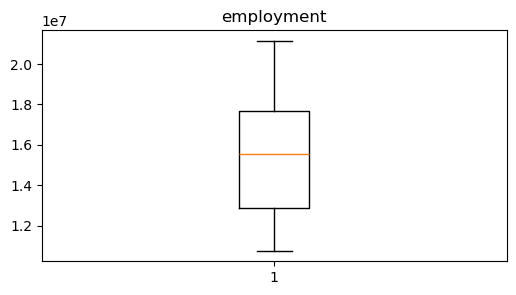

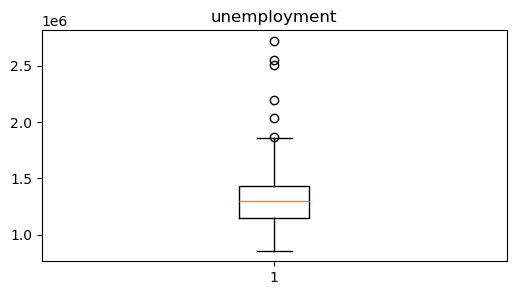

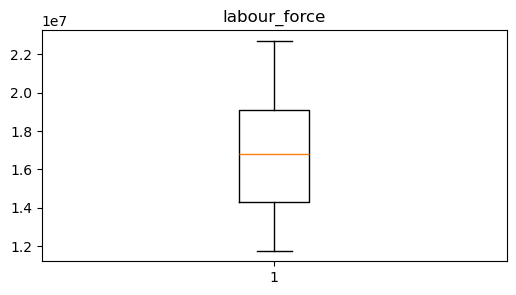

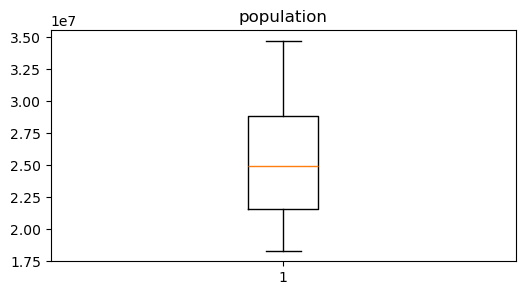

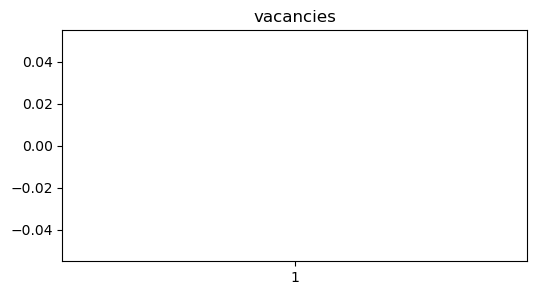

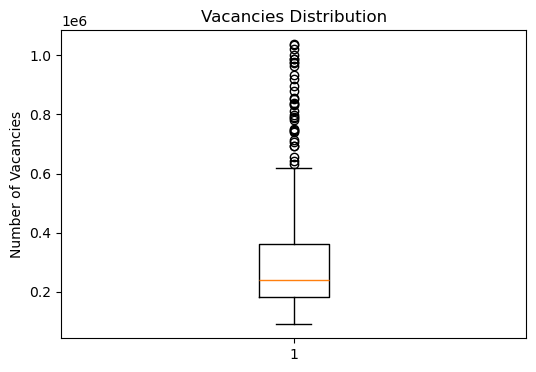

In [227]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(merged[col])
    plt.title(col)
    plt.show()
    import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(merged["vacancies"].dropna(), vert=True)
plt.title("Vacancies Distribution")
plt.ylabel("Number of Vacancies")
plt.show()

In [228]:
# ---------------------------------------------------
# STEP 1.12 — Construct labour market tightness
# ---------------------------------------------------

merged["theta"] = merged["vacancies"] / merged["unemployment"]

print("Theta summary:")
print(merged["theta"].describe())

display(merged[["month","vacancies","unemployment","theta"]].head())

Theta summary:
count    546.000000
mean       0.245373
std        0.159974
min        0.056304
25%        0.132125
50%        0.194534
75%        0.308222
max        0.993396
Name: theta, dtype: float64


,month,vacancies,unemployment,theta
0,1980-01-01,273345.0,877500,0.311504
1,1980-02-01,259678.0,894000,0.290468
2,1980-03-01,254211.0,901000,0.282143
3,1980-04-01,256944.0,908300,0.282885
4,1980-05-01,235077.0,923900,0.254440


In [229]:
# ---------------------------------------------------
# STEP 1.13 — Export final datasets
# ---------------------------------------------------

from pathlib import Path

processed_path = Path("../1_data/processed")

# Structural dataset (full)
merged.to_csv(processed_path / "final_dataset_full.csv", index=False)

# Modeling dataset (COVID gap removed)
model_df = merged[
    ~((merged["month"] >= "2020-04-01") &
      (merged["month"] <= "2020-09-01"))
]

model_df.to_csv(processed_path / "final_dataset_modeling.csv", index=False)

print("Datasets exported successfully.")
print("Full dataset shape:", merged.shape)
print("Model dataset shape:", model_df.shape)

Datasets exported successfully.
Full dataset shape: (552, 7)
Model dataset shape: (546, 7)
